#### Streamline workflows with Pipeline

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
# load the data
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
data.data.shape

(569, 30)

In [20]:
# check the data
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names
print(f"Target name: {target_names}\n")
print(f"Feature name: {feature_names}\n")
print(f"y values: {np.unique(y)}")

Target name: ['malignant' 'benign']

Feature name: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

y values: [0 1]


In [37]:
# split the dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, shuffle=True, random_state=1)

print(np.bincount(y_train), np.round(np.bincount(y_train) / np.sum(np.bincount(y_train)), 2))
print(np.bincount(y_test), np.round(np.bincount(y_test) / np.sum(np.bincount(y_test)), 2))

[159 267] [0.37 0.63]
[53 90] [0.37 0.63]


#### Combine transformers and estimators in a pipeline
**Pipeline StructureTransformers:**
[ StandardScaler ] → [ PCA ] → [ Logistic Regression ]

<img src='images/pipeline_workings.png' width=450>

In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

pipeline_lr = make_pipeline(StandardScaler(), PCA(n_components=2), LogisticRegression())
pipeline_lr.fit(X_train, y_train)
test_score = pipeline_lr.score(X_test, y_test)
print(f"Pipeline score: {test_score:.4f}")

preds = pipeline_lr.predict(X_test)
accuracy = accuracy_score(preds, y_test)
print(f"Accuracy: {accuracy:.4f}")

Pipeline score: 0.9371
Accuracy: 0.9371


#### Using holdout cross-validation to assess model performance
- The current practice is called the holdout method, for which we split the dataset into train and test set, and use the train set for training, and test set for testing. However, when we do the model selection process (hyperparameters finetuning process), the test set is exposed over and over again; hence, it will become a part of train data (leak), and the model will be more likely to overfit.
- The better way to use the holdout method for model selection is to separate the data into 3 parts: train, valid and test sets. The train set is used for training models, the valid set is used for performance evaluation during the model selection process. Once we are satisfied with the tuning of hyperparameter values, then we can estimate the model generalization with the test set. The disadvantage of the holdout method is that the performance is very sensitive to how we partition the training dataset into the train and test sets. 

<img src='images/holdout_method.png' width=500>

#### K-fold cross-validation
(1) In K-fold cross-validation, we randomly split the training dataset into k folds without replacement. \
(2) Here, k-1 folds are so-called training folds and used for the model training. \
(3) The remaining 1 fold is so-called the testing fold and used for the model evaluation during model selection. \
(4) We repeat (2) and (3) k times to obtain k models. \
(5) We calculate the average performance of the models based on the different, independent test folds. This average performance estimate is less sensitive than the holdout approach. \
(6) Train the model again with the best hyperparameter values on the whole train set. 

<img src='images/k_folds.png' width=500>

##### Stratified K-fold
- This is same as K-fold, but just preserve the class proportions in each fold to ensure that each fold is representative of the class proportions in the training dataset.

In [52]:
from sklearn.model_selection import StratifiedKFold

kfold = StratifiedKFold(n_splits=50).split(X_train, y_train)
scores = []

for k, (train, val) in enumerate(kfold):
    pipeline_lr.fit(X_train[train], y_train[train])
    score = pipeline_lr.score(X_train[val], y_train[val])
    scores.append(score)
    print(f"{k+1:02d}:, Class distribution: {np.bincount(y_train[train]), np.bincount(y_train[val])}, Acc: {score:0.3f}")

01:, Class distribution: (array([156, 261]), array([3, 6])), Acc: 1.000
02:, Class distribution: (array([156, 261]), array([3, 6])), Acc: 1.000
03:, Class distribution: (array([156, 261]), array([3, 6])), Acc: 1.000
04:, Class distribution: (array([156, 261]), array([3, 6])), Acc: 1.000
05:, Class distribution: (array([156, 261]), array([3, 6])), Acc: 0.889
06:, Class distribution: (array([156, 261]), array([3, 6])), Acc: 0.778
07:, Class distribution: (array([156, 261]), array([3, 6])), Acc: 1.000
08:, Class distribution: (array([156, 261]), array([3, 6])), Acc: 1.000
09:, Class distribution: (array([156, 261]), array([3, 6])), Acc: 1.000
10:, Class distribution: (array([156, 261]), array([3, 6])), Acc: 1.000
11:, Class distribution: (array([156, 261]), array([3, 6])), Acc: 0.778
12:, Class distribution: (array([156, 261]), array([3, 6])), Acc: 0.889
13:, Class distribution: (array([156, 261]), array([3, 6])), Acc: 1.000
14:, Class distribution: (array([156, 261]), array([3, 6])), Acc

##### Using cross_val_score for Stratified K-Folds

In [55]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(estimator=pipeline_lr,
                         X = X_train,
                         y = y_train,
                         cv = 10,
                         n_jobs=5) # distribute the 10 rounds of cross-validation to 2 CPUs, n_jobs=-1: all availalbe CPUs

print(f"CV accuracy scores: {scores}")
print(f"Accuracy score: {np.mean(scores)} +/- {np.std(scores)}")

CV accuracy scores: [0.95348837 0.93023256 0.93023256 1.         0.93023256 0.95348837
 0.97619048 0.92857143 0.97619048 1.        ]
Accuracy score: 0.9578626799557032 +/- 0.02722028866786388


#### Debugging algorithms with learning curve and validation curve

<img src='images/learning_curves.png' width=500>

**- Upper left:** high bias -> underfit the training data -> common approach: 
(1) increase the number of model parameters such as collecting/constructing additional features OR \
(2) decreasing the degree of regularization.

**- Upper right:** high variance -> overfit the training data -> common approach:\
(1) collect more training data \
(2) reduce the complexity of the model: feature selection and feature extraction \
(3) increase the regularization parameter

##### Learning curve: a plotting train accuracies and val accuracies as a function of sample size

In [67]:
from sklearn.model_selection import learning_curve

pipeline_lr = make_pipeline(StandardScaler(),
                            LogisticRegression(max_iter=1000))

train_sizes, train_scores, test_scores = learning_curve(estimator=pipeline_lr,
                                                        X = X_train,
                                                        y = y_train,
                                                        train_sizes=np.linspace(0.1, 1.0, 10),
                                                        cv=10,
                                                        n_jobs=2)

In [68]:
train_scores.shape

(10, 10)

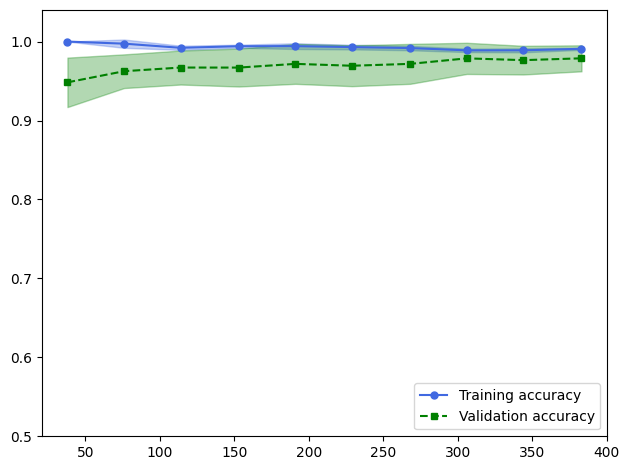

In [84]:
train_score_mean = np.mean(train_scores, axis=1)
train_score_std = np.std(train_scores, axis=1)
test_score_mean = np.mean(test_scores, axis=1)
test_score_std = np.std(test_scores, axis=1)

plt.plot(train_sizes, train_score_mean, color="royalblue", marker="o", markersize=5, label="Training accuracy")
plt.fill_between(train_sizes, train_score_mean + train_score_std, train_score_mean-train_score_std, color="royalblue", alpha=0.3)
plt.plot(train_sizes, test_score_mean, color="green", linestyle="--", marker="s", markersize=5, label="Validation accuracy")
plt.fill_between(train_sizes, test_score_mean - test_score_std, test_score_mean + test_score_std, color="green", alpha=0.3)
plt.ylim(0.5, 1.04)
plt.tight_layout()
plt.legend(loc="lower right")
plt.show()

##### Addressing over- and underfitting with validation curves: plotting train accuracies and test accuracies as a function of hyperparameters

In [85]:
from sklearn.model_selection import validation_curve

param_range = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

train_scores, test_scores = validation_curve(
    estimator=pipeline_lr,
    X=X_train,
    y=y_train,
    param_name='logisticregression__C',
    param_range=param_range,
    cv=10
)

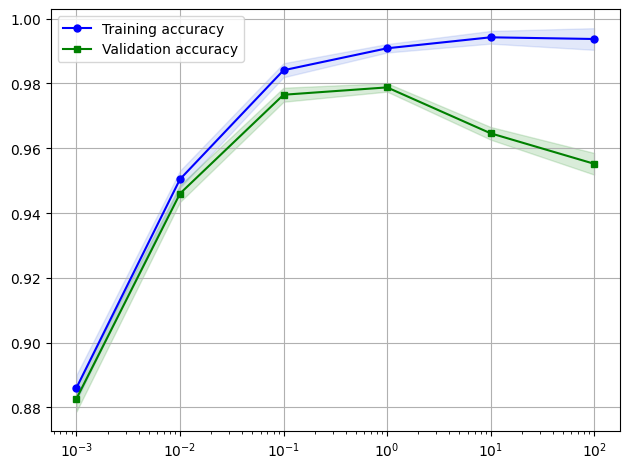

In [92]:
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.plot(param_range, train_mean, color="blue", marker="o", markersize=5, label="Training accuracy")
plt.fill_between(param_range, train_mean-train_std, train_mean+train_std, alpha=0.15, color="royalblue")
plt.plot(param_range, test_mean, color="green", marker="s", markersize=5, label="Validation accuracy")
plt.fill_between(param_range, test_mean-train_std, test_mean+train_std, alpha=0.15, color="green")
plt.legend()
plt.grid()
plt.xscale('log')
plt.tight_layout()
plt.show()

##### Fine-tuning machine learning models via Grid Search

In [93]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

pipe_svc = make_pipeline(StandardScaler(),
                         SVC(random_state=1))

param_range = [0.0001, 0.001, 0.1, 1.0, 10.0, 100.0, 1000.0]
param_grid = [{"svc__C": param_range,
               "svc__kernel": ['linear']},
               {"svc__C": param_range,
                "svc__gamma": param_range,
                "svc__kernel": ['rbf']}]

gs = GridSearchCV(estimator=pipe_svc,
                  param_grid=param_grid,
                  scoring="accuracy",
                  cv=10,
                  refit=True,
                  n_jobs=-1)

gs = gs.fit(X_train, y_train)

print(gs.best_score_)
print(gs.best_params_)
print(gs.best_index_)

0.9835548172757476
{'svc__C': 0.1, 'svc__kernel': 'linear'}
2


In [94]:
clf = gs.best_estimator_
clf.fit(X_train, y_train)
print(f"Test accuracy: {clf.score(X_test, y_test):.3f}")

Test accuracy: 0.972


#### Exploring hyperparameter configurations more widely with Randomized Search
- Grid Search is exhaustive search, it's very expensive in practice.
- An alternative approach is Randomized Search.
- In Randomized Search, we draw hyperparameter configurations randomly from distributions (or discrete sets).
- It still allows to explore a wider range of hyperparameter value settings in a more cost- and time-effective manner.

In [97]:
import scipy.stats
param_range = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

In [101]:
np.random.seed(1)
param_range = scipy.stats.loguniform(0.0001, 1000.0)
param_range.rvs(10)
# X ~ loguniform[10^-4, 10^-3] -> log(X) = z ~ U[-4,3] -> find z -> X = 10^z

array([8.30145146e-02, 1.10222804e+01, 1.00184520e-04, 1.30715777e-02,
       1.06485687e-03, 4.42965766e-04, 2.01289666e-03, 2.62376594e-02,
       5.98924832e-02, 5.91176467e-01])

In [106]:
from sklearn.model_selection import RandomizedSearchCV
pipe_svc = make_pipeline(StandardScaler(),
                         SVC(random_state=1))

param_range = scipy.stats.loguniform(0.0001, 1000.0)

param_grid = [{"svc__C": param_range, "svc__kernel": ['linear']},
              {"svc__C": param_range, "svc__kernel": ['rbf'], "svc__gamma": param_range}]

rs = RandomizedSearchCV(estimator=pipe_svc,
                        param_distributions=param_grid,
                        scoring="accuracy",
                        refit=True,
                        n_iter=20,
                        cv=10,
                        random_state=1,
                        n_jobs=-1)

rs.fit(X_train, y_train)
print(rs.best_score_)
print(rs.best_params_)

0.9788482834994463
{'svc__C': 0.05971247755848463, 'svc__kernel': 'linear'}


##### Nested CV

In [111]:
param_range = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

param_grid = [{"svc__C": param_range, "svc__kernel": ['linear']}, 
              {"svc__C": param_range, "svc__gamma": param_range, "svc__kernel":['rbf']}]

gs = GridSearchCV(estimator = pipe_svc,
                  param_grid = param_grid,
                  scoring = "accuracy",
                  cv = 2)

scores = cross_val_score(gs, X_train, y_train, scoring="accuracy", cv=5)
print(f"CV accuracy: {np.mean(scores)} +/- {np.std(scores)}")

CV accuracy: 0.9788782489740082 +/- 0.013710936044533691


In [112]:
scores

array([0.97674419, 0.96470588, 1.        , 0.96470588, 0.98823529])

In [109]:
from sklearn.tree import DecisionTreeClassifier
gs = GridSearchCV(estimator = DecisionTreeClassifier(random_state=0),
                  param_grid = [{"max_depth": [1,2,3,4,5,6,7,None]}],
                  scoring = "accuracy",
                  cv = 2)

scores = cross_val_score(gs, X_train, y_train, scoring="accuracy", cv=5)
print(f"CV accuracy: {np.mean(scores)} +/- {np.std(scores)}")

CV accuracy: 0.9249521203830369 +/- 0.026129607990463266


**Conclusion**: as we can see, the performance of the SVM model is notably better than the performance of the decision tree.